# Maximin Sampling
**Objective:** Generate an experimental design for a Co/MIM/TEA mixture using a greedy Maximin algorithm. This maximizes the spread of points across the feasible composition space to ensure diverse sampling.

### import necessary libraries

In [1]:
import numpy as np
from scipy.spatial.distance import cdist
from typing import Sequence, Tuple
import ternary
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from matplotlib.colors import PowerNorm


### Feasible Lattice Generation
We define the feasible space with the following constraints:
* **Total Volume:** 8.0 mL
* **Step Size:** 0.1 mL
* **Constraints:**
    * Co > 0 (Must be present)
    * MIM > 0 (Must be present)
    * TEA >= 0 (Optional)

In [2]:
def build_feasible_lattice(total_ml=8.0, step_ml=0.1):
    """
    Generate all feasible (Co, MIM, TEA) on a lattice with:
    - Co > 0, MIM > 0, TEA >= 0
    - Co + MIM + TEA = total_ml
    - each component is a multiple of step_ml
    Returns an array of shape (N, 3) in mL.
    """
    units = int(round(total_ml / step_ml))
    pts = []
    # a, b, c are lattice units for Co, MIM, TEA respectively
    for a in range(1, units):             # Co units > 0
        for b in range(1, units - a + 1):     # MIM units > 0
            c = units - a - b             # TEA units >= 0
            if c < 0:
                continue
            pts.append((a, b, c))
    pts = np.array(pts, dtype=float) * step_ml
    return pts

### Greedy Maximin Selection
To select $N$ diverse samples:
1. Normalize the grid to the composition space [0, 1].
2. Pick a random starting point.
3. Iteratively select the next point that maximizes the Euclidean distance to the set of already selected points.

In [3]:
def maximin_scaled(grid_ml, n_samples=20, random_state=42):
    """
    Greedy farthest-point (maximin) selection on a simplex:
    - Work in composition space by dividing by the total volume (sum=1).
    - Start from a reproducible random feasible point.
    Returns indices of selected points.
    """
    rng = np.random.default_rng(random_state)
    total_ml = np.sum(grid_ml[0])              # constant = 8.0
    grid_scaled = grid_ml / total_ml           # to compositions in [0,1], sum=1

    selected_idx = [rng.integers(0, len(grid_scaled))]
    selected_pts = [grid_scaled[selected_idx[0]]]

    for _ in range(n_samples - 1):
        dists = cdist(grid_scaled, np.array(selected_pts))
        min_d = np.min(dists, axis=1)
        next_idx = int(np.argmax(min_d))
        selected_idx.append(next_idx)
        selected_pts.append(grid_scaled[next_idx])
    return np.array(selected_idx)

### Sampling Wrapper
This function combines the lattice generation and the maximin selection into a single callable interface.

In [4]:
def initial_sampling(n_init=20, total_ml=8.0, step_ml=0.1, random_state=111):
    """
    Produce n_init initial samples satisfying:
    - Co > 0, MIM > 0, TEA >= 0
    - sum = total_ml, step = step_ml
    - No TEA cap, no duplication
    Returns an array (n_init, 3) in mL.
    """
    grid_pts = build_feasible_lattice(total_ml=total_ml, step_ml=step_ml)
    idx = maximin_scaled(grid_pts, n_samples=n_init, random_state=random_state)
    return grid_pts[idx]

In [5]:

# ---------- plots ----------
def plot_sampling_space(scale_ml: float = 8.0):
    s = int(round(scale_ml))  # 8
    fig, tax = ternary.figure(scale=s)
    tax.gridlines(multiple=1, color="0.8", linewidth=0.8, zorder=0)  # 1 mL grid
    tax.boundary(linewidth=2.0, zorder=0)
    tax.left_corner_label("", offset=0)

    # Add a manually positioned label (Co2+)
    tax.annotate(
        r"Co$^{2+}$ (mL)",
        position=(0, 1, 0),            # bottom-left vertex (Co2+=0, 2-mIm=8, TEA=0)
        fontsize=14,
        textcoords="offset points",
        xytext=(-35,-60),
        ha='center', va='center'
    )

    # tax.right_corner_label("2-mIm (mL)", fontsize=14, offset=0.4)
    tax.right_corner_label("", offset=0)
    tax.annotate(
        r"2-mIm (mL)",
        position=(0, 1, 0),
        fontsize=14,
        xytext=(315, -60),
        textcoords="offset points",
        ha='center', va='center'
    )

    tax.top_corner_label("TEA (mL)", fontsize=14, offset=0.2)
    
    tax.ticks(axis='lbr', multiple=1, linewidth=1,
              tick_formats="%d", fontsize=12, offset=0.015)
    tax.clear_matplotlib_ticks()
    tax.get_axes().axis('off')
    plt.tight_layout()
    return tax, s

def plot_initial_samples(tax, X_ml: np.ndarray, marker_size: float = 60, marker_color: str = "red"):
    X_ml = np.asarray(X_ml, float)
    ternary_pts = [(row[1], row[2], row[0]) for row in X_ml]  # (MIM, TEA, Co)
    for p in ternary_pts:
        tax.scatter([p], marker='o', color=marker_color, s=marker_size,
                    edgecolors=marker_color, facecolors='none', vmin=None, vmax=None)


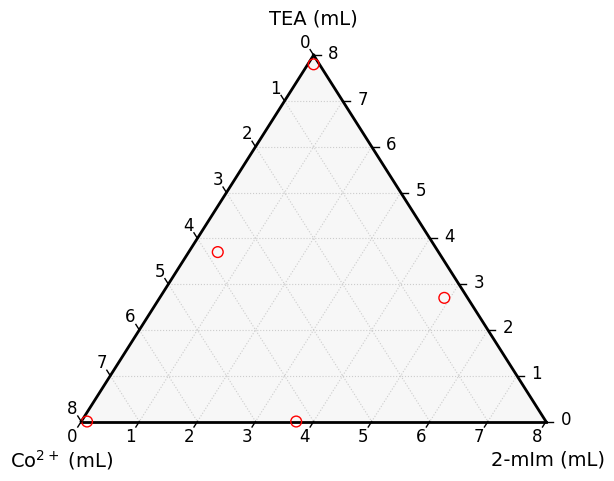

[[0.4 4.9 2.7]
 [7.9 0.1 0. ]
 [0.1 0.1 7.8]
 [3.8 0.5 3.7]
 [4.3 3.7 0. ]]


In [6]:
tax, _ = plot_sampling_space(scale_ml=8.0)        # draw feasible grid / triangle
samples = initial_sampling(n_init=5, total_ml=8.0, step_ml=0.1, random_state=42)
plot_initial_samples(tax, samples)
plt.show()
print(samples)

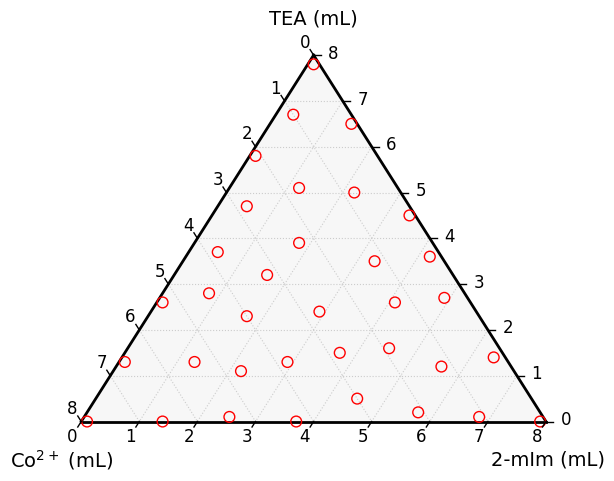

[[0.4 4.9 2.7]
 [7.9 0.1 0. ]
 [0.1 0.1 7.8]
 [3.8 0.5 3.7]
 [4.3 3.7 0. ]
 [0.1 7.9 0. ]
 [0.8 2.2 5. ]
 [2.1 5.7 0.2]
 [5.4 1.3 1.3]
 [2.7 2.9 2.4]
 [2.1 0.1 5.8]
 [0.2 6.4 1.4]
 [2.3 1.8 3.9]
 [1.2 3.3 3.5]
 [1.9 4.5 1.6]
 [0.1 1.4 6.5]
 [6.6 1.4 0. ]
 [5.3 0.1 2.6]
 [4.  1.7 2.3]
 [6.6 0.1 1.3]
 [5.4 2.5 0.1]
 [3.8 2.9 1.3]
 [3.  4.5 0.5]
 [1.1 6.8 0.1]
 [0.1 3.4 4.5]
 [1.  0.3 6.7]
 [2.8 0.5 4.7]
 [1.7 1.2 5.1]
 [1.2 5.6 1.2]
 [2.8 3.7 1.5]
 [1.3 4.1 2.6]
 [0.2 4.2 3.6]
 [3.2 1.6 3.2]
 [4.7 2.2 1.1]
 [4.4 0.8 2.8]]


In [7]:
tax, _ = plot_sampling_space(scale_ml=8.0)        # draw feasible grid / triangle
samples = initial_sampling(n_init=35, total_ml=8.0, step_ml=0.1, random_state=42)
plot_initial_samples(tax, samples)
plt.show()
print(samples)